# Аналитика для CheeseRadar

## Импорт библиотек

In [3]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## Чтение дампа данных
Данные - dm.dm_cheese_top_products

In [6]:
df = pl.read_csv('/content/cheese_dump.csv', has_header=True, separator=";")
df.head()

Name,Store,Price,Price Per Kg,Discount,Rating,Fat Content,Weight,Unit,Is Sliced,Is Bzmj,Is Creamy,Scraped At,Rank,Rank Best Rating,Rank Best Discount,In Top 10 Price,In Top 10 Rating,In Top 10 Discount,In Any Top,Reccommendation Type,Ranked At
str,str,f64,f64,i64,f64,i64,i64,str,bool,bool,bool,str,i64,i64,i64,bool,bool,bool,bool,str,str
"""Сыр Умалат Рбили творожный с х…","""Магнит""",99.99,769.15,41,4.9,65,130,"""г""",false,false,true,"""2025-12-22T07:01:48""",1,7,2,true,true,true,true,"""Самый дешевый""","""2025-12-22T12:00:41.235852+00:…"
"""Сыр творожный Violette Ароматн…","""Магнит""",109.99,785.64,31,4.9,70,140,"""г""",false,false,true,"""2025-12-22T07:01:48""",2,6,1,true,true,true,true,"""Самый дешевый""","""2025-12-22T12:00:41.235852+00:…"
"""Сыр творожный Савушкин Прованс…","""Магнит""",124.99,833.27,19,4.9,60,150,"""г""",false,false,true,"""2025-12-22T07:01:48""",3,3,3,true,true,true,true,"""Самый дешевый""","""2025-12-22T12:00:41.235852+00:…"
"""Сыр Радость вкуса Львиное серд…","""Магнит""",154.99,861.06,null,4.6,45,180,"""г""",false,false,false,"""2025-12-22T07:01:48""",4,11,5,true,false,false,true,"""Самый дешевый""","""2025-12-22T12:00:41.235852+00:…"
"""Плавленый сыр со вкусом Индейк…","""Магнит""",199.99,869.52,25,4.7,40,230,"""г""",false,false,true,"""2025-12-22T07:01:48""",5,10,8,true,true,true,true,"""Самый дешевый""","""2025-12-22T12:00:41.235852+00:…"


## Первичное EDA

In [24]:
print(f"Размерность данных: {df.shape[0]} строк, {df.shape[1]} колонок")
print(f"Колонки: {df.columns}")

Размерность данных: 13 строк, 22 колонок
Колонки: ['Name', 'Store', 'Price', 'Price Per Kg', 'Discount', 'Rating', 'Fat Content', 'Weight', 'Unit', 'Is Sliced', 'Is Bzmj', 'Is Creamy', 'Scraped At', 'Rank', 'Rank Best Rating', 'Rank Best Discount', 'In Top 10 Price', 'In Top 10 Rating', 'In Top 10 Discount', 'In Any Top', 'Reccommendation Type', 'Ranked At']


In [9]:
df.describe()

statistic,Name,Store,Price,Price Per Kg,Discount,Rating,Fat Content,Weight,Unit,Is Sliced,Is Bzmj,Is Creamy,Scraped At,Rank,Rank Best Rating,Rank Best Discount,In Top 10 Price,In Top 10 Rating,In Top 10 Discount,In Any Top,Reccommendation Type,Ranked At
str,str,str,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,str,str
"""count""","""13""","""13""",13.0,13.0,10.0,13.0,13.0,13.0,"""13""",13.0,13.0,13.0,"""13""",13.0,13.0,13.0,13.0,13.0,13.0,13.0,"""13""","""13"""
"""null_count""","""0""","""0""",0.0,0.0,3.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""","""0"""
"""mean""",null,null,181.910769,1083.316923,29.2,4.692308,45.230769,163.846154,null,0.076923,0.0,0.615385,null,7.0,7.0,7.0,0.769231,0.769231,0.769231,0.923077,null,null
"""std""",null,null,106.423775,396.589973,6.613118,0.500769,17.814572,42.532039,null,null,null,null,null,3.89444,3.89444,3.89444,null,null,null,null,null,null
"""min""","""Плавленый сыр со вкусом Индейк…","""Магнит""",99.99,769.15,19.0,3.1,0.0,100.0,"""г""",0.0,0.0,0.0,"""2025-12-22T07:01:48""",1.0,1.0,1.0,0.0,0.0,0.0,0.0,"""Лучшая скидка""","""2025-12-22T12:00:41.235852+00:…"
"""25%""",null,null,124.99,861.06,25.0,4.7,40.0,140.0,null,null,null,null,null,4.0,4.0,4.0,null,null,null,null,null,null
"""50%""",null,null,149.99,933.27,29.0,4.9,45.0,150.0,null,null,null,null,null,7.0,7.0,7.0,null,null,null,null,null,null
"""75%""",null,null,179.99,999.93,34.0,4.9,60.0,180.0,null,null,null,null,null,10.0,10.0,10.0,null,null,null,null,null,null
"""max""","""Сырное ассорти нарезка Premier…","""Магнит""",499.97,1999.88,41.0,5.0,70.0,250.0,"""г""",1.0,0.0,1.0,"""2025-12-22T07:01:48""",13.0,13.0,13.0,1.0,1.0,1.0,1.0,"""Стандартный""","""2025-12-22T12:00:41.235852+00:…"


In [51]:
df = df.with_columns(pl.col('Discount').fill_null(0))

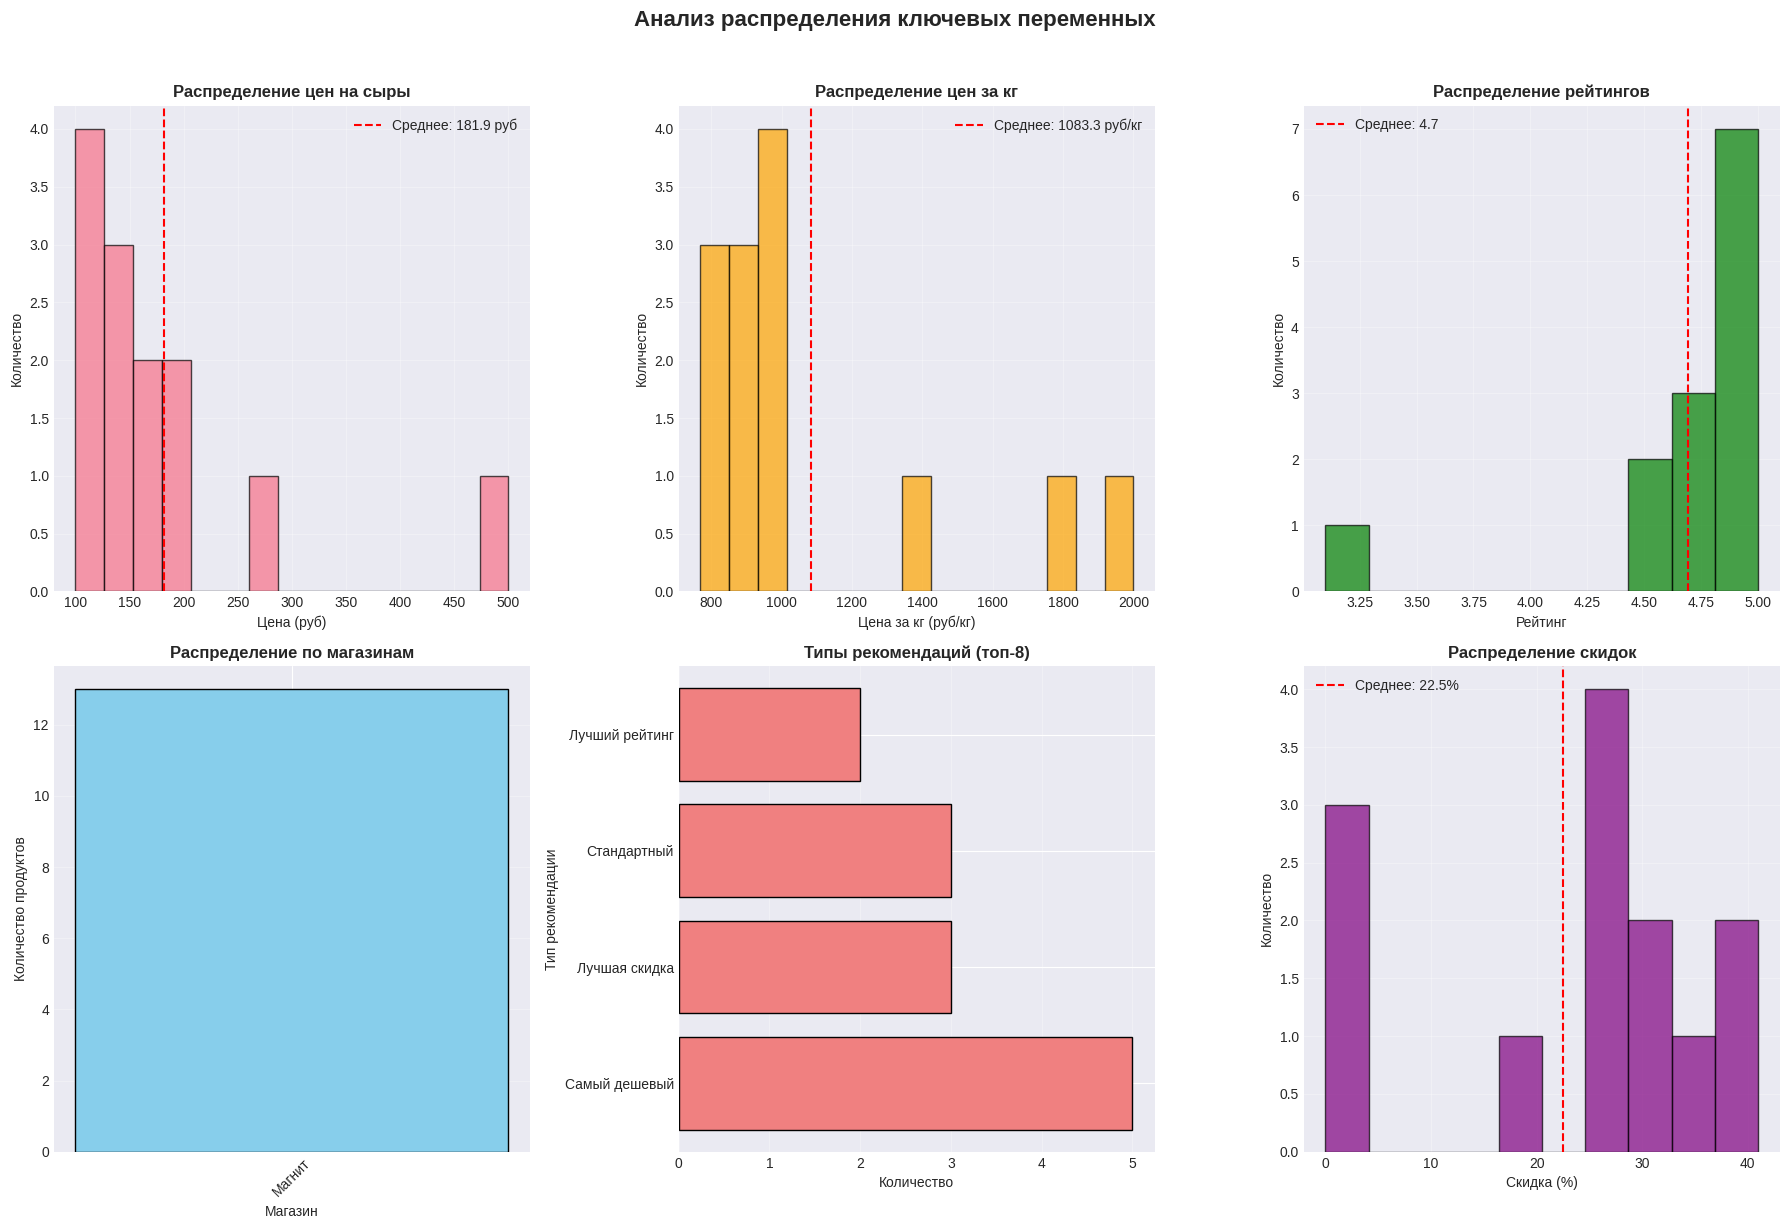

In [32]:
# Визуализация распределения
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Анализ распределения ключевых переменных', fontsize=16, fontweight='bold', y=1.02)

# Распределение Price
price_data = df['Price'].to_numpy()
axes[0, 0].hist(price_data, bins=15, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(np.mean(price_data), color='red', linestyle='--', label=f'Среднее: {np.mean(price_data):.1f} руб')
axes[0, 0].set_title('Распределение цен на сыры', fontweight='bold')
axes[0, 0].set_xlabel('Цена (руб)')
axes[0, 0].set_ylabel('Количество')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Распределение Price Per Kg
price_per_kg_data = df['Price Per Kg'].to_numpy()
axes[0, 1].hist(price_per_kg_data, bins=15, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].axvline(np.mean(price_per_kg_data), color='red', linestyle='--', label=f'Среднее: {np.mean(price_per_kg_data):.1f} руб/кг')
axes[0, 1].set_title('Распределение цен за кг', fontweight='bold')
axes[0, 1].set_xlabel('Цена за кг (руб/кг)')
axes[0, 1].set_ylabel('Количество')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Распределение Rating
rating_data = df['Rating'].to_numpy()
axes[0, 2].hist(rating_data, bins=10, edgecolor='black', alpha=0.7, color='green')
axes[0, 2].axvline(np.mean(rating_data), color='red', linestyle='--', label=f'Среднее: {np.mean(rating_data):.1f}')
axes[0, 2].set_title('Распределение рейтингов', fontweight='bold')
axes[0, 2].set_xlabel('Рейтинг')
axes[0, 2].set_ylabel('Количество')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Магазины
store_counts = df['Store'].value_counts().sort('count', descending=True)
store_names = [row[0] for row in store_counts.rows()]
store_values = [row[1] for row in store_counts.rows()]

axes[1, 0].bar(store_names, store_values, color='skyblue', edgecolor='black')
axes[1, 0].set_title('Распределение по магазинам', fontweight='bold')
axes[1, 0].set_xlabel('Магазин')
axes[1, 0].set_ylabel('Количество продуктов')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Типы рекомендаций
recommend_col = 'Reccommendation Type'
if recommend_col in df.columns:
    rec_counts = df[recommend_col].value_counts().sort('count', descending=True)
    rec_names = [row[0] for row in rec_counts.head(8).rows()]
    rec_values = [row[1] for row in rec_counts.head(8).rows()]

    axes[1, 1].barh(rec_names, rec_values, color='lightcoral', edgecolor='black')
    axes[1, 1].set_title('Типы рекомендаций (топ-8)', fontweight='bold')
    axes[1, 1].set_xlabel('Количество')
    axes[1, 1].set_ylabel('Тип рекомендации')
    axes[1, 1].grid(True, alpha=0.3, axis='x')

# Скидки
if 'Discount' in df.columns:
    discount_data = df.filter(pl.col('Discount').is_not_null())['Discount'].to_numpy()
    if len(discount_data) > 0:
        axes[1, 2].hist(discount_data, bins=10, edgecolor='black', alpha=0.7, color='purple')
        axes[1, 2].axvline(np.mean(discount_data), color='red', linestyle='--', label=f'Среднее: {np.mean(discount_data):.1f}%')
        axes[1, 2].set_title('Распределение скидок', fontweight='bold')
        axes[1, 2].set_xlabel('Скидка (%)')
        axes[1, 2].set_ylabel('Количество')
        axes[1, 2].legend()
        axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

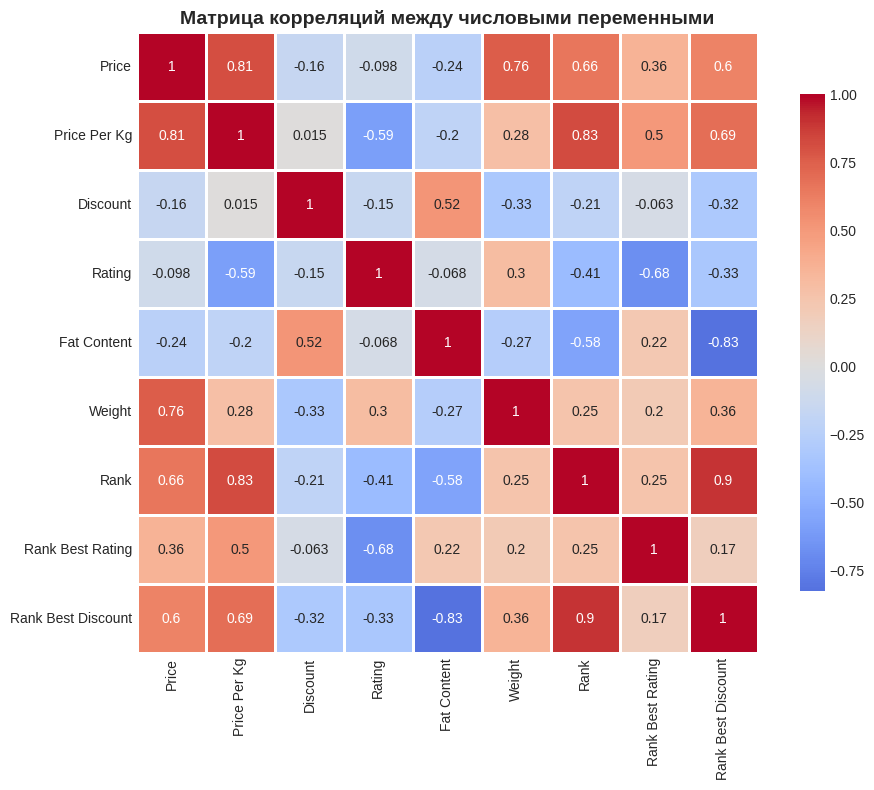

In [35]:
# Корреляционный анализ

numeric_cols = [col for col, dtype in df.schema.items() if dtype.is_numeric()]
numeric_df = df.select(numeric_cols)
corr_matrix = numeric_df.corr()

# Визуализация корреляций
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix.to_numpy(),
            annot=True,
            cmap='coolwarm',
            center=0,
            xticklabels=corr_matrix.columns,
            yticklabels=corr_matrix.columns,
            square=True,
            linewidths=1,
            cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляций между числовыми переменными', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Интересная отрицательная корреляция между величиной жирности сыра и рейтингом высокой скидки. Получается, что из отобранного ТОПа в целом большей скидкой обладают более жирные сыры. Рассмотрим вопрос подробнее

In [43]:
# Анализ по жирности

# Создаем категории жирности
fat_categories = (
    df.with_columns([
        pl.when(pl.col('Fat Content').is_in([1, 20])) # добавлено после обнаружения жирности 0 (не найдена в названии)
          .then(pl.lit('Низкая (<=20%)'))
          .when(pl.col('Fat Content') <= 40)
          .then(pl.lit('Средняя (21-40%)'))
          .when(pl.col('Fat Content') <= 60)
          .then(pl.lit('Высокая (41-60%)'))
          .otherwise(pl.lit('Очень высокая (>60%)'))
          .alias('Fat_Category')
    ])
)

# Статистика по категориям
fat_stats = (
    fat_categories.group_by('Fat_Category')
    .agg([
        pl.len().alias('Количество'),
        pl.mean('Price').alias('Ср_цена'),
        pl.mean('Price Per Kg').alias('Ср_цена_за_кг'),
        pl.mean('Rating').alias('Ср_рейтинг')
    ])
    .sort('Количество', descending=True)
)

print("Статистика по категориям жирности:")
fat_stats

Статистика по категориям жирности:


Fat_Category,Количество,Ср_цена,Ср_цена_за_кг,Ср_рейтинг
str,u32,f64,f64,f64
"""Высокая (41-60%)""",6,142.49,1052.451667,4.533333
"""Средняя (21-40%)""",5,259.984,1242.724,4.8
"""Очень высокая (>60%)""",2,104.99,777.395,4.9


По результатам анализа выходит, что наиболее жирные сыры в среднем более дешевые, что говорит либо о меньшем спросе на них, либо о худшем качестве

In [50]:
# Сводная статистика

summary_stats = [
    ("Общее количество продуктов", df.shape[0]),
    ("Количество магазинов", df['Store'].n_unique()),
    ("Средняя цена продукта", f"{df['Price'].mean():.2f} руб"),
    ("Диапазон цен", f"{df['Price'].min():.2f} - {df['Price'].max():.2f} руб"),
    ("Средний рейтинг", f"{df['Rating'].mean():.2f}"),
    ("Продуктов с рейтингом >=4.5", f"{(df['Rating'] >= 4.5).sum()}"),
    ("Средний вес продукта", f"{df['Weight'].mean():.1f} г"),
]

for stat_name, stat_value in summary_stats:
    print(f"{stat_name}: {stat_value}")

Общее количество продуктов: 13
Количество магазинов: 1
Средняя цена продукта: 181.91 руб
Диапазон цен: 99.99 - 499.97 руб
Средний рейтинг: 4.69
Продуктов с рейтингом >=4.5: 12
Средний вес продукта: 163.8 г
